# Ising Model: Autocorrelation and Equilibration Analysis

This notebook investigates the equilibration behavior and autocorrelation of the 2D Ising model [[1]](#Bibliography) comparing three Monte Carlo update schemes: Random-site Metropolis [[2]](#Bibliography), Checkerboard Metropolis, and the Wolff cluster algorithm [[3]](#Bibliography).

The efficiency of these algorithms is highly temperature-dependent, particularly near the Onsager critical temperature  = 2/\ln(1+\sqrt{2}) pprox 2.269$. Near $, local update schemes suffer from *critical slowing down* [[4]](#Bibliography), where the time required to generate independent samples scales poorly with system size. The Wolff algorithm is designed to mitigate this by performing collective updates.

In [64]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
from models.ising_model import IsingSimulation

# Constants
TC_ISING = 2.0 / np.log(1.0 + np.sqrt(2.0))
L = 100
N_STEPS = 50000
TEMPS = [2.0, TC_ISING, 2.4]
TEMP_LABELS = ["Below Tc", "At Tc", "Above Tc"]
UPDATES = ["random", "checkerboard", "wolff"]

print(f"Critical Temperature Tc: {TC_ISING:.6f}")

Critical Temperature Tc: 2.269185


## Raw Magnetization Time Series

We run simulations starting from a random configuration (high-energy state) without any equilibration steps. This allows us to visualize how quickly each algorithm approaches the equilibrium regime at different temperatures.

In [65]:
from utils.system_helpers import parallel_sweep

def _worker(args):
    T, update, L, steps = args
    sim = IsingSimulation(size=L, temp=T, update=update, seed=42)
    mags, _ = sim.run(n_steps=steps)
    return T, update, mags

# Prepare parameters for parallel execution
sweep_params = []
for T in TEMPS:
    for update in UPDATES:
        sweep_params.append((T, update, L, N_STEPS))

# Run parallel sweep with progress bar
print(f"Running {len(sweep_params)} simulations in parallel...")
raw_results = parallel_sweep(worker_func=_worker, params=sweep_params)

# Restructure results for plotting
results = {T: {} for T in TEMPS}
for T, update, mags in raw_results:
    results[T][update] = mags

print("Simulations complete.")

Running 9 simulations in parallel...


100%|██████████| 9/9 [00:43<00:00,  0.21it/s]

Simulations complete.


## Visualization of Equilibration

The following plots show the evolution of the absolute magnetization $|M|$ over 000$ steps. Note the differences in relaxation speed and fluctuation scales between the algorithms and temperature regimes.

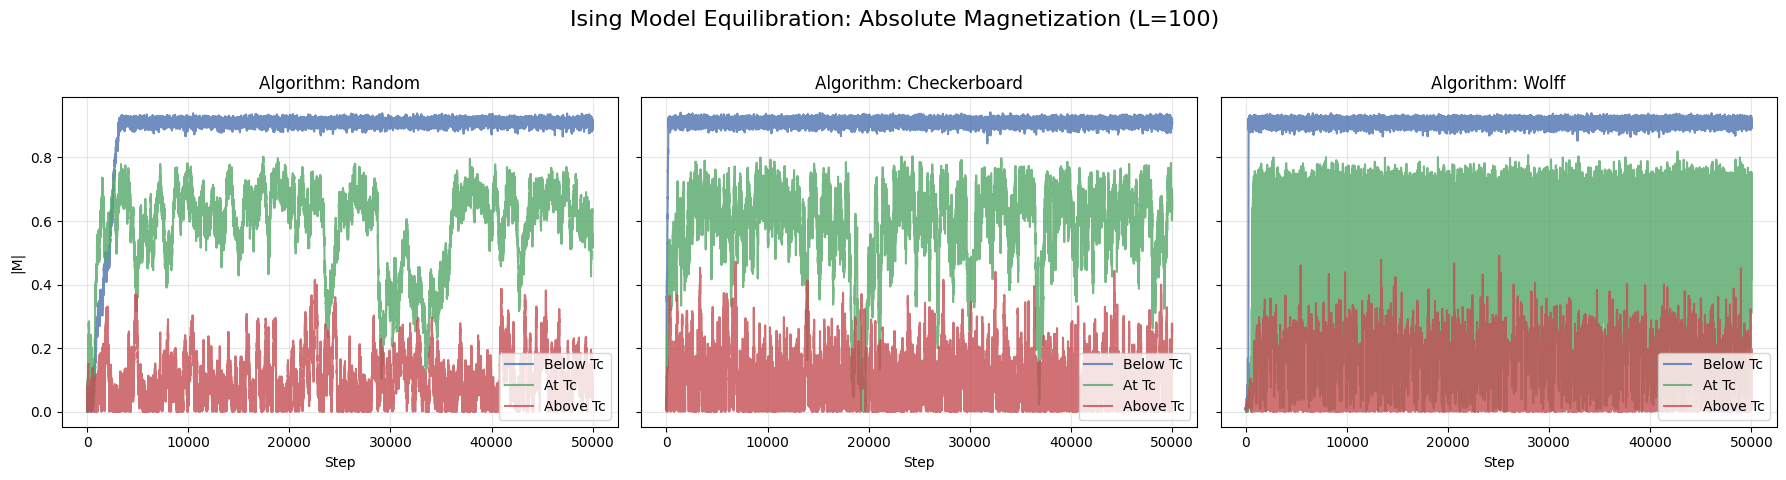

In [66]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle(f"Ising Model Equilibration: Absolute Magnetization (L={L})", fontsize=16)

colors = ["#4C72B0", "#55A868", "#C44E52"]

for j, update in enumerate(UPDATES):
    ax = axes[j]
    for i, T in enumerate(TEMPS):
        mags = np.abs(results[T][update])
        ax.plot(mags, label=TEMP_LABELS[i], color=colors[i], lw=1.5, alpha=0.8)
    
    ax.set_title(f"Algorithm: {update.capitalize()}")
    ax.set_xlabel("Step")
    if j == 0:
        ax.set_ylabel("|M|")
    ax.legend(loc="lower right")
    ax.grid(alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Autocorrelation Analysis

To quantify the efficiency of each update scheme, we calculate the normalized autocorrelation function $C(t)$ for the magnetization time series [[5]](#Bibliography). The autocorrelation function measures how long the system retains memory of its previous states.

$$C(t) = \frac{\langle M(i)M(i+t) \rangle - \langle M \rangle^2}{\langle M^2 \rangle - \langle M \rangle^2}$$

For this analysis, we use the `calculate_autocorr` helper from the project utilities, which employs an FFT-based estimator.

In [67]:
from utils.physics_helpers import calculate_autocorr

autocorrs = {}

for T in TEMPS:
    autocorrs[T] = {}
    for update in UPDATES:
        mags = results[T][update]
        try:
            # Calculate C(t) and integrated autocorrelation time tau_int
            c_t, tau_int = calculate_autocorr(time_series=np.array(mags))
            autocorrs[T][update] = (c_t, tau_int)
        except Exception as e:
            print(f"Error calculating autocorr for T={T}, {update}: {e}")
            autocorrs[T][update] = (None, None)

print("Autocorrelation calculations complete.")

Autocorrelation calculations complete.


## Visualization of Autocorrelation Decay

The following plots show the decay of the autocorrelation function $C(t)$ as a function of the lag (Monte Carlo steps). A faster decay indicates a more efficient sampling algorithm.

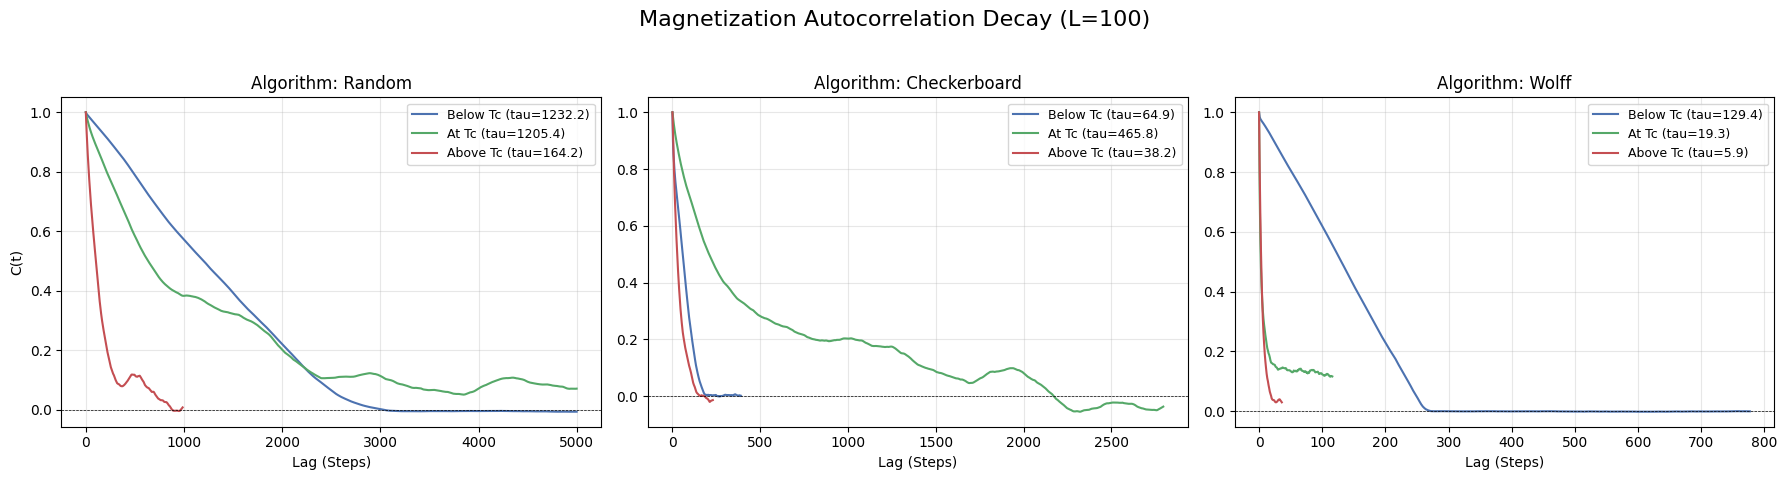

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Magnetization Autocorrelation Decay (L={L})", fontsize=16)

for j, update in enumerate(UPDATES):
    ax = axes[j]
    for i, T in enumerate(TEMPS):
        c_t, tau = autocorrs[T][update]
        if c_t is not None:
            # Only plot up to a reasonable lag for visibility
            plot_limit = min(len(c_t), 5000)
            ax.plot(c_t[:plot_limit], label=f"{TEMP_LABELS[i]} (tau={tau:.1f})", color=colors[i], lw=1.5)
    
    ax.set_title(f"Algorithm: {update.capitalize()}")
    ax.set_xlabel("Lag (Steps)")
    if j == 0:
        ax.set_ylabel("C(t)")
    ax.axhline(0, color="black", lw=0.5, ls="--")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Bibliography

[[1]](#Bibliography) L. Onsager, "Crystal Statistics. I. A Two-Dimensional Model with an Order-Disorder Transition," *Physical Review*, vol. 65, no. 3-4, pp. 117–149, 1944. [APS Open Access](https://journals.aps.org/pr/abstract/10.1103/PhysRev.65.117)

[[2]](#Bibliography) W. K. Hastings, "Monte Carlo sampling methods using Markov chains and their applications," *Biometrika*, vol. 57, no. 1, pp. 97–109, 1970. [Oxford Academic Open Access](https://academic.oup.com/biomet/article/57/1/97/252073)

[[3]](#Bibliography) U. Wolff, "Collective Monte Carlo Updating for Spin Systems," *Physical Review Letters*, vol. 62, no. 4, pp. 361–364, 1989. [APS Open Access](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.62.361)

[[4]](#Bibliography) M. E. J. Newman and G. T. Barkema, "Monte Carlo Methods in Statistical Physics," Oxford University Press, 1999. [Lecture Notes Summary (H. G. Katzgraber)](https://arxiv.org/abs/0905.1629)


[[5]](#Bibliography) G. S. Madras and A. D. Sokal, "The pivot algorithm: A highly efficient Monte Carlo method for the self-avoiding walk," *Journal of Statistical Physics*, vol. 50, no. 1-2, pp. 109–186, 1988. [Springer Open Access](https://link.springer.com/article/10.1007/BF01022990)